In [4]:
import pandas as pd
import numpy as np
import torch
import strats
import datetime
import os
import pickle

print(datetime.datetime.now())


2025-06-11 19:04:12.178382


In [2]:
mimic_lab = pd.read_feather('mimic_data_lab.feather')
eicu_lab = pd.read_feather('eicu_data_lab.feather')

In [9]:
mimic_cf = mimic_lab[mimic_lab['itemid']=='creatinine']
eicu_cf = eicu_lab[eicu_lab['itemid']=='creatinine']

mimic_cf = mimic_cf[mimic_cf['valuenum']<33]
eicu_cf = eicu_cf[eicu_cf['value']<33]

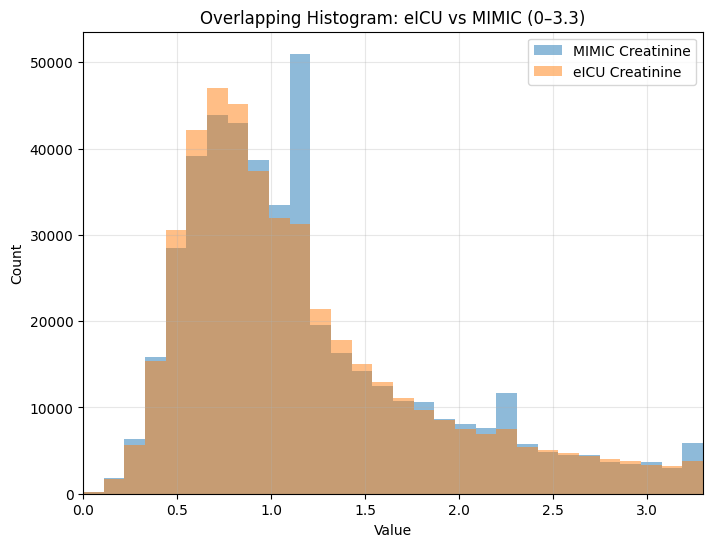

In [21]:
import matplotlib.pyplot as plt
eicu_vals  = eicu_cf['value']
mimic_vals = mimic_cf['valuenum']

mask_e = (eicu_vals  >= 0) & (eicu_vals  <= 3.3)
mask_m = (mimic_vals >= 0) & (mimic_vals <= 3.3)

# 2) Plot overlapping histograms
plt.figure(figsize=(8, 6))
plt.hist(mimic_vals[mask_m], bins=30, range=(0, 3.3), alpha=0.5, label='MIMIC Creatinine')
plt.hist(eicu_vals[mask_e],  bins=30, range=(0, 3.3), alpha=0.5, label='eICU Creatinine')
plt.xlim(0, 3.3)
plt.xlabel('Value')
plt.ylabel('Count')
plt.title('Overlapping Histogram: eICU vs MIMIC (0–3.3)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [15]:
# (1) 그룹별 최소값 계산
min_vals = (
    eicu_cf
    .groupby('patientunitstayid', as_index=False)['value']
    .min()
    .rename(columns={'value': 'min_value'})
)

print(min_vals.head())

# (2) 원본 DataFrame에 병합해서 각 row에 최소값 컬럼 추가하기
eicu_cf_with_min = eicu_cf.merge(min_vals, on='patientunitstayid', how='left')
eicu_cf_with_min.drop_duplicates(subset=['patientunitstayid'], inplace=True)

   patientunitstayid  min_value
0             141168       1.95
1             141194       1.97
2             141233       0.80
3             141244       0.59
4             141265       0.71


In [16]:
# (1) 그룹별 최소값 계산
min_vals = (
    mimic_cf
    .groupby('hadm_id', as_index=False)['valuenum']
    .min()
    .rename(columns={'valuenum': 'min_value'})
)

print(min_vals.head())

# (2) 원본 DataFrame에 병합해서 각 row에 최소값 컬럼 추가하기
mimic_cf_with_min = mimic_cf.merge(min_vals, on='hadm_id', how='left')
mimic_cf_with_min.drop_duplicates(subset=['hadm_id'], inplace=True)

    hadm_id  min_value
0  20000147        0.6
1  20001305        0.8
2  20001361        2.5
3  20001494        0.9
4  20001770        0.7


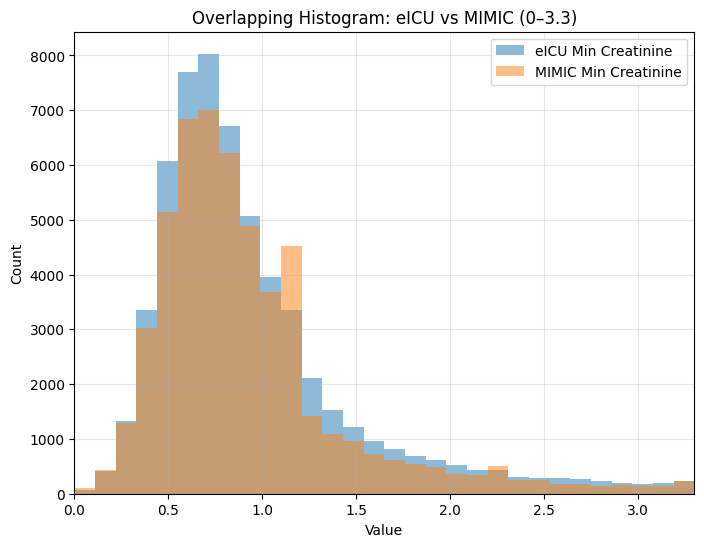

In [20]:
eicu_vals  = eicu_cf_with_min['min_value']
mimic_vals = mimic_cf_with_min['min_value']

mask_e = (eicu_vals  >= 0) & (eicu_vals  <= 3.3)
mask_m = (mimic_vals >= 0) & (mimic_vals <= 3.3)

# 2) Plot overlapping histograms
plt.figure(figsize=(8, 6))
plt.hist(eicu_vals[mask_e],  bins=30, range=(0, 3.3), alpha=0.5, label='eICU Min Creatinine')
plt.hist(mimic_vals[mask_m], bins=30, range=(0, 3.3), alpha=0.5, label='MIMIC Min Creatinine')
plt.xlim(0, 3.3)
plt.xlabel('Value')
plt.ylabel('Count')
plt.title('Overlapping Histogram: eICU vs MIMIC (0–3.3)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [6]:
with open('clip_bounds.pkl', 'rb') as f:
    clip_bounds_all = pickle.load(f)

with open('item_dict_total.pkl', 'rb') as f:
    item_dict_total = pickle.load(f)

In [2]:
mimic_static = pd.read_feather('mimic_data_static.feather')

def process_static(static):
    # Treat only in-hospital death
    static.loc[static['hospital_expire_flag'] == 0, 'deathtime'] = None
    static = static.loc[:,['hadm_id', 'deathtime']]
    static = static.rename(columns={'hadm_id': 'hadm_id', 'deathtime' : 'death_offset'})
    unique_static_ids = static['hadm_id'].unique()
    return static, unique_static_ids

mimic_outcome, mimic_ids = process_static(mimic_static)

data_vital = pd.read_feather('mimic_data_vital.feather').rename(columns={'valuenum' : 'value'})
data_lab = pd.read_feather('mimic_data_lab.feather').rename(columns={'valuenum' : 'value'})
data_treatment = pd.read_feather('mimic_data_treatment.feather').rename(columns={'valuenum' : 'value'})

data = pd.concat([data_vital, data_lab, data_treatment])

# Factorize the 'item' column and get the mapping
encoded_total, actual_class_total = pd.factorize(data['itemid'])
data.loc[:,'itemid'] = encoded_total.astype(int)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

data = data.dropna(subset=['value'])

item_dict_total = dict(zip(actual_class_total, range(len(actual_class_total))))
emb_idx_total = len(item_dict_total)

# 재현성 유지를 위해 seed를 고정하고 섞습니다.
np.random.seed(42)
np.random.shuffle(mimic_ids)

# 예: 80%를 train, 나머지를 valid로 사용
train_size = int(len(mimic_ids) * 0.6)
valid_size = int(len(mimic_ids) * 0.8)
train_hadm_ids = mimic_ids[:train_size]
valid_hadm_ids = mimic_ids[train_size:valid_size]
test_hadm_ids = mimic_ids[valid_size:]

train_df = data[data['hadm_id'].isin(train_hadm_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_hadm_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_hadm_ids)].copy().reset_index(drop=True)

train_outcome_df = mimic_outcome[mimic_outcome['hadm_id'].isin(train_hadm_ids)].copy()
valid_outcome_df = mimic_outcome[mimic_outcome['hadm_id'].isin(valid_hadm_ids)].copy()
test_outcome_df = mimic_outcome[mimic_outcome['hadm_id'].isin(test_hadm_ids)].copy()

In [3]:
print(actual_class_total)

Index(['resp_rate', 'heart_rate', 'map', 'temperature', 'gcs', 'pao2', 'ph',
       'fio2', 'wbc', 'platelets', 'creatinine', 'hematocrit', 'sodium',
       'glucose', 'bilirubin', 'albumin', 'lactate', 'urine', 'a10', 'a_drug',
       'a_supplements', 'b', 'c01', 'c_else', 'h', 'l', 'm', 'n', 'r', 'v',
       'fluid', 'ventilator'],
      dtype='object')


In [4]:
data.drop_duplicates(inplace=True, subset=['hadm_id', 'itemid', 'offset'])

In [5]:
data['itemid'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [6]:
def compute_trimmed_stats(values: pd.Series, low_pct: float, high_pct: float):
    """
    values: 해당 그룹의 value Series
    low_pct, high_pct: 잘라낼 분위수 (예: 0.01, 0.99)
    
    반환: (trimmed_mean, trimmed_std)
    """
    lower_bound = values.quantile(low_pct)
    upper_bound = values.quantile(high_pct)
    trimmed = values[(values >= lower_bound) & (values <= upper_bound)]
    return trimmed.mean(), trimmed.std()

def calculate_all_stats(df: pd.DataFrame):
    # 결과를 담을 리스트
    results = []

    # itemid별로 그룹화
    grouped = df.groupby('itemid')

    for item_id, group in grouped:
        vals = group['value']

        # 1) 전체(아웃라이어 제거 없음) 평균/표준편차
        orig_mean = vals.mean()
        orig_std  = vals.std()

        # 2) 상하위 1% 제거
        mean_1pct, std_1pct = compute_trimmed_stats(vals, 0.01, 0.99)

        # 3) 상하위 3% 제거
        mean_3pct, std_3pct = compute_trimmed_stats(vals, 0.03, 0.97)

        # 4) 상하위 5% 제거
        mean_5pct, std_5pct = compute_trimmed_stats(vals, 0.05, 0.95)

        # 결과 한 줄로 정리
        results.append({
            'itemid': item_id,
            'orig_mean': orig_mean,
            'orig_std': orig_std,
            'mean_1pct': mean_1pct,
            'std_1pct': std_1pct,
            'mean_3pct': mean_3pct,
            'std_3pct': std_3pct,
            'mean_5pct': mean_5pct,
            'std_5pct': std_5pct
        })

    # 리스트를 DataFrame으로
    df_stats = pd.DataFrame(results)
    return df_stats

# -----------------------------------------------
# 실제 사용 예: data 라는 DF가 hadm_id, itemid, offset, value를 가진다고 가정
# -----------------------------------------------
df_stats = calculate_all_stats(data)